In [88]:
import pandas as pd
import os
import joblib
import json

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    matthews_corrcoef, roc_auc_score
)


In [95]:
df = pd.read_csv(r"C:\Users\Jyoti\BITS\ML Assignment 2\Dry_Bean.csv")
print("Dataset shape:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head())
print("Encoded sample (first 10):", y_encoded[:10])
print("Encoded sample (next 10):", y_encoded[10:20])



Dataset shape: (13611, 17)

Column names: ['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'AspectRation', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent', 'Solidity', 'roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2', 'ShapeFactor3', 'ShapeFactor4', 'Class']

First 5 rows:
    Area  Perimeter  MajorAxisLength  MinorAxisLength  AspectRation  Eccentricity  ConvexArea  EquivDiameter    Extent  Solidity  roundness  Compactness  ShapeFactor1  ShapeFactor2  ShapeFactor3  ShapeFactor4  Class
0  28395    610.291       208.178117       173.888747      1.197191      0.549812       28715     190.141097  0.763923  0.988856   0.958027     0.913358      0.007332      0.003147      0.834222      0.998724  SEKER
1  28734    638.018       200.524796       182.734419      1.097356      0.411785       29172     191.272751  0.783968  0.984986   0.887034     0.953861      0.006979      0.003564      0.909851      0.998430  SEKER
2  29380    624.110       212.826130       175.93

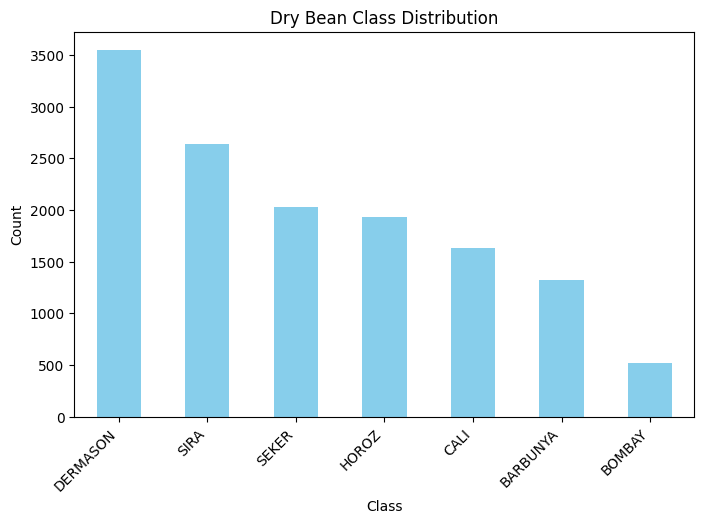

In [96]:
# Visualize class distribution
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
df["Class"].value_counts().plot(kind="bar", color="skyblue")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Count")
plt.title("Dry Bean Class Distribution")
plt.show()


In [97]:
# Encode labels
from sklearn.preprocessing import LabelEncoder, StandardScaler
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(df["Class"])


In [99]:
# Scale features
X = df.drop("Class", axis=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [100]:
# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)



Training set shape: (10888, 16)
Test set shape: (2723, 16)


In [101]:
# Save scaler and encoder for app.py
import joblib, os
os.makedirs("model", exist_ok=True)
joblib.dump(scaler, "model/scaler.pkl")
joblib.dump(label_encoder, "model/label_encoder.pkl")


['model/label_encoder.pkl']

In [124]:
# Balanced test subset: equal samples per class
balanced_df = df.groupby("Class", group_keys=False).apply(lambda x: x.sample(85, random_state=42))

print("Balanced subset shape:", balanced_df.shape)
print("Class distribution in balanced subset:")
print(balanced_df["Class"].value_counts())

# Save for app
balanced_df.to_csv("test_data.csv", index=False)
print("Balanced test_data.csv saved successfully.")

Balanced subset shape: (595, 17)
Class distribution in balanced subset:
Class
BARBUNYA    85
BOMBAY      85
CALI        85
DERMASON    85
HOROZ       85
SEKER       85
SIRA        85
Name: count, dtype: int64
Balanced test_data.csv saved successfully.


C:\Users\Jyoti\AppData\Local\Temp\ipykernel_16692\2137777208.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  balanced_df = df.groupby("Class", group_keys=False).apply(lambda x: x.sample(85, random_state=42))


In [104]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=500, random_state=42)
log_reg.fit(X_train, y_train)
y_pred = log_reg.predict(X_test)
y_pred_prob = log_reg.predict_proba(X_test)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
mcc = matthews_corrcoef(y_test, y_pred)
y_test_bin = label_binarize(y_test, classes=range(len(label_encoder.classes_)))
auc = roc_auc_score(y_test_bin, y_pred_prob, average='weighted', multi_class='ovr')

print("Logistic Regression Results:",)
print(f"Accuracy: {accuracy:.4f}")
print(f"AUC: {auc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"MCC: {mcc:.4f}")

joblib.dump(log_reg, "model/logistic_regression.pkl")
with open("model/logistic_regression_metrics.json", "w") as f:
    json.dump({"Accuracy": accuracy, "AUC": auc, "Precision": precision,
               "Recall": recall, "F1 Score": f1, "MCC": mcc}, f, indent=4)

Logistic Regression Results:
Accuracy: 0.9210
AUC: 0.9934
Precision: 0.9219
Recall: 0.9210
F1 Score: 0.9212
MCC: 0.9046


In [105]:
from sklearn.tree import DecisionTreeClassifier

from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)
y_pred_prob = dt.predict_proba(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
mcc = matthews_corrcoef(y_test, y_pred)
y_test_bin = label_binarize(y_test, classes=range(len(label_encoder.classes_)))
auc = roc_auc_score(y_test_bin, y_pred_prob, average='weighted', multi_class='ovr')

print("Decision Tree Results:"), 
print(f"Accuracy: {accuracy:.4f}")
print(f"AUC: {auc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"MCC: {mcc:.4f}")

joblib.dump(dt, "model/decision_tree.pkl")
with open("model/decision_tree_metrics.json", "w") as f:
    json.dump({"Accuracy": accuracy, "AUC": auc, "Precision": precision,
               "Recall": recall, "F1 Score": f1, "MCC": mcc}, f, indent=4)


Decision Tree Results:
Accuracy: 0.8920
AUC: 0.9334
Precision: 0.8917
Recall: 0.8920
F1 Score: 0.8916
MCC: 0.8696


In [107]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
y_pred_prob = knn.predict_proba(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
mcc = matthews_corrcoef(y_test, y_pred)
y_test_bin = label_binarize(y_test, classes=range(len(label_encoder.classes_)))
auc = roc_auc_score(y_test_bin, y_pred_prob, average='weighted', multi_class='ovr')

print("KNN Results:"), 
print(f"Accuracy: {accuracy:.4f}")
print(f"AUC: {auc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"MCC: {mcc:.4f}")

joblib.dump(knn, "model/knn.pkl")
with open("model/knn_metrics.json", "w") as f:
    json.dump({"Accuracy": accuracy, "AUC": auc, "Precision": precision,
               "Recall": recall, "F1 Score": f1, "MCC": mcc}, f, indent=4)

KNN Results:
Accuracy: 0.9170
AUC: 0.9813
Precision: 0.9177
Recall: 0.9170
F1 Score: 0.9172
MCC: 0.8996


In [109]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred = nb.predict(X_test)
y_pred_prob = nb.predict_proba(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
mcc = matthews_corrcoef(y_test, y_pred)
y_test_bin = label_binarize(y_test, classes=range(len(label_encoder.classes_)))
auc = roc_auc_score(y_test_bin, y_pred_prob, average='weighted', multi_class='ovr')

print("Naive Bayes Results:") , 
print(f"Accuracy: {accuracy:.4f}")
print(f"AUC: {auc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"MCC: {mcc:.4f}")

joblib.dump(nb, "model/naive_bayes.pkl")
with open("model/naive_bayes_metrics.json", "w") as f:
    json.dump({"Accuracy": accuracy, "AUC": auc, "Precision": precision,
               "Recall": recall, "F1 Score": f1, "MCC": mcc}, f, indent=4)

Naive Bayes Results:
Accuracy: 0.8979
AUC: 0.9902
Precision: 0.9007
Recall: 0.8979
F1 Score: 0.8981
MCC: 0.8773


In [110]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
y_pred_prob = rf.predict_proba(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
mcc = matthews_corrcoef(y_test, y_pred)
y_test_bin = label_binarize(y_test, classes=range(len(label_encoder.classes_)))
auc = roc_auc_score(y_test_bin, y_pred_prob, average='weighted', multi_class='ovr')

print("Random Forest Results:"),
print(f"Accuracy: {accuracy:.4f}")
print(f"AUC: {auc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"MCC: {mcc:.4f}")

joblib.dump(rf, "model/random_forest.pkl")
with open("model/random_forest_metrics.json", "w") as f:
    json.dump({"Accuracy": accuracy, "AUC": auc, "Precision": precision,
               "Recall": recall, "F1 Score": f1, "MCC": mcc}, f, indent=4)

Random Forest Results:
Accuracy: 0.9207
AUC: 0.9914
Precision: 0.9209
Recall: 0.9207
F1 Score: 0.9207
MCC: 0.9041


In [118]:
from xgboost import XGBClassifier

xgb = XGBClassifier(use_label_encoder=False, eval_metric="mlogloss", random_state=42)
xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)
y_pred_prob = xgb.predict_proba(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
mcc = matthews_corrcoef(y_test, y_pred)
y_test_bin = label_binarize(y_test, classes=range(len(label_encoder.classes_)))
auc = roc_auc_score(y_test_bin, y_pred_prob, average='weighted', multi_class='ovr')

print("XGBoost Results:"), 
print(f"Accuracy: {accuracy:.4f}")
print(f"AUC: {auc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"MCC: {mcc:.4f}")

joblib.dump(xgb, "model/xgboost.pkl")
with open("model/xgboost_metrics.json", "w") as f:
    json.dump({"Accuracy": accuracy, "AUC": auc, "Precision": precision,
               "Recall": recall, "F1 Score": f1, "MCC": mcc}, f, indent=4)

C:\Users\Jyoti\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\xgboost\training.py:199: UserWarning: [16:08:31] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Results:
Accuracy: 0.9240
AUC: 0.9937
Precision: 0.9241
Recall: 0.9240
F1 Score: 0.9239
MCC: 0.9080


In [117]:
import pandas as pd
import json

# List of model names corresponding to your saved JSON files
model_names = [
    "logistic_regression",
    "decision_tree",
    "knn",
    "naive_bayes",
    "random_forest",
    "xgboost"
]

results = []
for name in model_names:
    with open(f"model/{name}_metrics.json", "r") as f:
        metrics = json.load(f)
    metrics["Model"] = name.replace("_", " ").title()
    results.append(metrics)

# Create DataFrame for comparison
results_df = pd.DataFrame(results)
results_df.set_index("Model", inplace=True)

# Print table
print("Comparison of Models (metrics side-by-side):")
results_df.style.format("{:.4f}")


Comparison of Models (metrics side-by-side):


,Accuracy,AUC,Precision,Recall,F1 Score,MCC
Model,,,,,,
Logistic Regression,0.9210,0.9934,0.9219,0.9210,0.9212,0.9046
Decision Tree,0.8920,0.9334,0.8917,0.8920,0.8916,0.8696
Knn,0.9170,0.9813,0.9177,0.9170,0.9172,0.8996
Naive Bayes,0.8979,0.9902,0.9007,0.8979,0.8981,0.8773
Random Forest,0.9207,0.9914,0.9209,0.9207,0.9207,0.9041
Xgboost,0.9240,0.9937,0.9241,0.9240,0.9239,0.9080


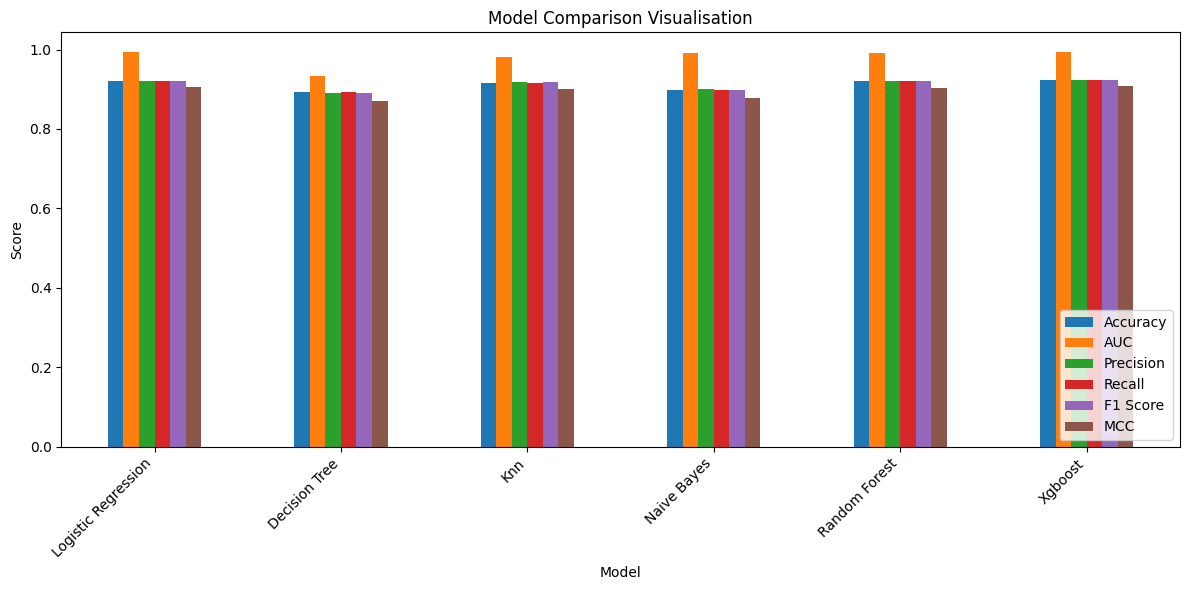

In [121]:
# Visualisation of all metrics
metrics_to_plot = ["Accuracy", "AUC", "Precision", "Recall", "F1 Score", "MCC"]

results_df[metrics_to_plot].plot(kind="bar", figsize=(12,6))
plt.title("Model Comparison Visualisation")
plt.ylabel("Score")
plt.xticks(rotation=45, ha="right")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [122]:
# Export comparison table to CSV
results_df.to_csv("model_comparision.csv", index=True)
print("Model comparison table saved as model_comparision.csv")

Model comparison table saved as Test_Data.csv
